In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from mad.configs import sputnik_stages, sputnik, titan2_stages
from mad.configs import EARTH_SETTINGS
from mad.objs import Planet, PlanetConfig
from mad.objs import BallisticMissileConfig, MissileStage, MissileStageConfig, BallisticMissile, SatelliteConfig, SputnikConfig
from mad.guidances import NoGuidance, LEOInsertionGuidance
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points

logger = SourceLogger()

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 1000
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.random_point_at_surface(name="Launchpad", altitude=10)
target = earth.point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")

In [5]:
missile_stages = [MissileStage(MissileStageConfig(**stage_cfg)) for stage_cfg in sputnik_stages]

missile_guidance = LEOInsertionGuidance(planet=earth, 
                                        perigee_altitude_m = 200_000,
                                        apogee_altitude_m=400_000,
                                        # target=target,
                                        min_turn_altitude_m=200,
                                        turn_end_altitude_m=180_000,)

sputnik_guidance = NoGuidance(planet=earth, target=target)

payload_cfg = SputnikConfig(**sputnik, guidance = sputnik_guidance)

missile_cfg = BallisticMissileConfig(stages=missile_stages, 
                                     guidance=missile_guidance, 
                                     payloads=[payload_cfg], 
                                     payload_separation_interval=5.0)
semyorka = BallisticMissile(position=launchpad.position.copy(), cfg=missile_cfg, name="Semyorka")

semyorka


BallisticMissile Semyorka, active.
Stages: Bloc_BVGD, Bloc_A.
Available deltaV: 10459.25 m/s.
Guidance: LEOInsertionGuidance.
Payloads: Sputnik.

In [6]:
dt = 1.0
max_time = 15_000.

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[semyorka],
)

df = sim.results

15:55:55 | INFO     | Simulation   | 0.00s - Starting simulation.
15:55:55 | INFO     | Missile      | 59.00s - Bloc_BVGD ran out of propellant at 59.00.
15:55:55 | INFO     | Missile      | 59.00s - Semyorka - Bloc_BVGD separated at 59.00.
15:55:55 | INFO     | Simulation   | 59.00s - New objects spawned this step: ['Bloc_BVGD']
15:55:55 | INFO     | Guidance     | 331.00s - Semyorka Orbit insertion achieved at altitude 204.7 km, v_horiz = 7845.3 m/s (target 7846.4 m/s).
15:55:55 | INFO     | Satellite    | 331.00s - Sputnik released into orbit -- Beep Beep!
15:55:55 | INFO     | Missile      | 331.00s - Semyorka released payload Sputnik_1 at 331.00.
15:55:55 | INFO     | Missile      | 331.00s - Semyorka has released all payloads at 331.00. Stages deactivated.
15:55:55 | INFO     | Missile      | 331.00s - Semyorka - Bloc_A separated at 331.00.
15:55:55 | INFO     | Missile      | 331.00s - Semyorka inactivated at 331.00.
15:55:55 | INFO     | Simulation   | 331.00s - New objects spa

In [7]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

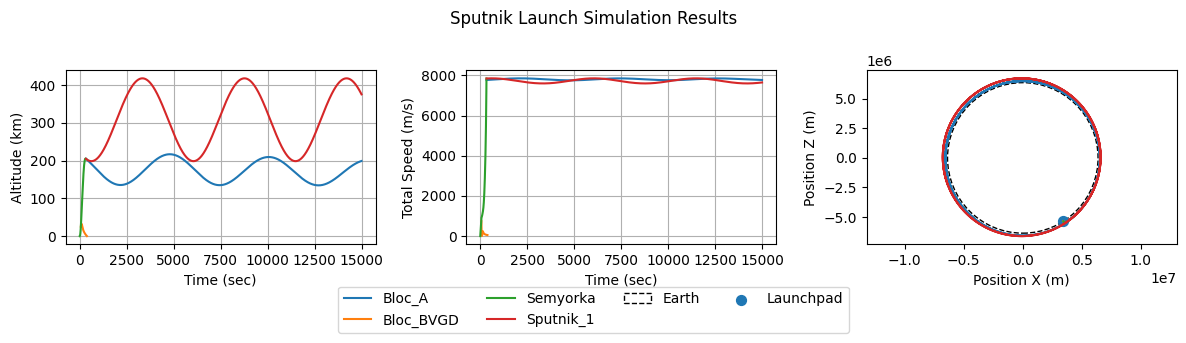

In [11]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 3))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[2], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

plot_2D_planet_with_points(earth, points = [launchpad], ax=ax[2], display="planet")
ax[2].set_xlabel("Position X (m)")
ax[2].set_ylabel("Position Z (m)")
ax[2].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Sputnik Launch Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)
